In [ ]:
%load_ext autoreload
%autoreload 2

import ast
import gc

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# from helpers import plotLightCurveFromDF, sampleRandomKIC, saveLightCurveFromDF
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_recall_fscore_support, precision_score,
                             recall_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set model training device. For Apple Silicon, the device is mps.

In [11]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)


mps


In [12]:
df = pd.read_parquet(r"/Users/wayfinder/Code/fault-in-our-stars/model-building/local-assets/PREPROCESSED_FLUX_TCN_INPUT.parquet")
# df


In [13]:
df['label'].value_counts().sort_index()


label
0    1972
1    3049
2    7520
3    2980
Name: count, dtype: int64

In [14]:
class LightCurveDataset(Dataset):
    def __init__(self, df):
        self.x = df["x"].values
        self.y = df["label"].values

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x = torch.tensor(self.x[idx], dtype=torch.float32)  # (seq_len,)
        x = x.unsqueeze(0)  # (1, seq_len)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_ds = LightCurveDataset(train_df)
val_ds = LightCurveDataset(val_df)
test_ds = LightCurveDataset(test_df)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [16]:
classes = np.unique(train_df["label"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(weights, dtype=torch.float32)

print(f"Class weights:\n{class_weights}")


Class weights:
tensor([1.9681, 1.2727, 0.5160, 1.3020])


In [17]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv = nn.Conv1d(
            in_ch, 
            out_ch, 
            kernel_size,
            padding=padding, 
            dilation=dilation
        )
        self.bn = nn.BatchNorm1d(out_ch)

        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return out + self.residual(x)


class TCN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = TCNBlock(1, 32, dilation=1)
        self.block2 = TCNBlock(32, 64, dilation=2)
        self.block3 = TCNBlock(64, 128, dilation=4)
        # self.block4 = TCNBlock(128, 256, dilation=8)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (B, 1, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        # x = self.block4(x)

        x = self.pool(x).squeeze(-1)  # (B, 128)
        return self.fc(x)


In [18]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = TCN(num_classes=len(classes)).to(device)

# criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [20]:
model.load_state_dict(torch.load("../local-assets/TCN-100-D.pt"))
model.eval()


TCN(
  (block1): TCNBlock(
    (conv): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
  )
  (block2): TCNBlock(
    (conv): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(4,), dilation=(2,))
    (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual): Conv1d(32, 64, kernel_size=(1,), stride=(1,))
  )
  (block3): TCNBlock(
    (conv): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(8,), dilation=(4,))
    (bn): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (residual): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [37]:
for x, _ in train_loader:
    print(x.shape)
    break


torch.Size([64, 1, 20000])


In [46]:
from torchviz import make_dot

model.eval()
x = torch.randn(1, 1, 20_000)  # example input

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
x = x.to(device)

y = model(x).to(device)

dot = make_dot(y, params=dict(model.named_parameters()))
dot.render("model_architecture", format="png")


'model_architecture.png'

In [44]:
from torchinfo import summary

summary(model, input_size=(1, 1, 20000))


Layer (type:depth-idx)                   Output Shape              Param #
TCN                                      [1, 4]                    --
├─TCNBlock: 1-1                          [1, 32, 20000]            --
│    └─Conv1d: 2-1                       [1, 32, 20000]            192
│    └─BatchNorm1d: 2-2                  [1, 32, 20000]            64
│    └─Conv1d: 2-3                       [1, 32, 20000]            64
├─TCNBlock: 1-2                          [1, 64, 20000]            --
│    └─Conv1d: 2-4                       [1, 64, 20000]            10,304
│    └─BatchNorm1d: 2-5                  [1, 64, 20000]            128
│    └─Conv1d: 2-6                       [1, 64, 20000]            2,112
├─TCNBlock: 1-3                          [1, 128, 20000]           --
│    └─Conv1d: 2-7                       [1, 128, 20000]           41,088
│    └─BatchNorm1d: 2-8                  [1, 128, 20000]           256
│    └─Conv1d: 2-9                       [1, 128, 20000]           8,32

In [21]:
def compute_metrics(y_true, y_pred, labels=None, target_names=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return metrics, report, cm


def evaluate_model(model, loader, device, labels=None, target_names=None):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(y.numpy())

    metrics, report, cm = compute_metrics(
        all_targets,
        all_preds,
        labels=labels,
        target_names=target_names
    )

    return metrics, report, cm, all_targets, all_preds


In [23]:
def runInference(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    return all_preds, all_labels


In [24]:
labelToClass = (
    df[["label", "class"]]
    .drop_duplicates()
    .sort_values("label")
    .set_index("label")["class"]
    .to_dict()
)

classNames = [labelToClass[i] for i in sorted(labelToClass.keys())]

print(labelToClass)


{0: 'CONFIRMED', 1: 'ECLIPSING BINARY STAR', 2: 'FALSE POSITIVE', 3: 'VARIABLE STAR'}


In [25]:
y_pred, y_true = runInference(model, test_loader)
y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [26]:
class_names = [labelToClass[i] for i in sorted(labelToClass.keys())]


Confusion matrix:


,Pred CONFIRMED,Pred ECLIPSING BINARY STAR,Pred FALSE POSITIVE,Pred VARIABLE STAR
True CONFIRMED,274,7,9,6
True ECLIPSING BINARY STAR,66,345,24,22
True FALSE POSITIVE,392,19,434,283
True VARIABLE STAR,3,5,80,359


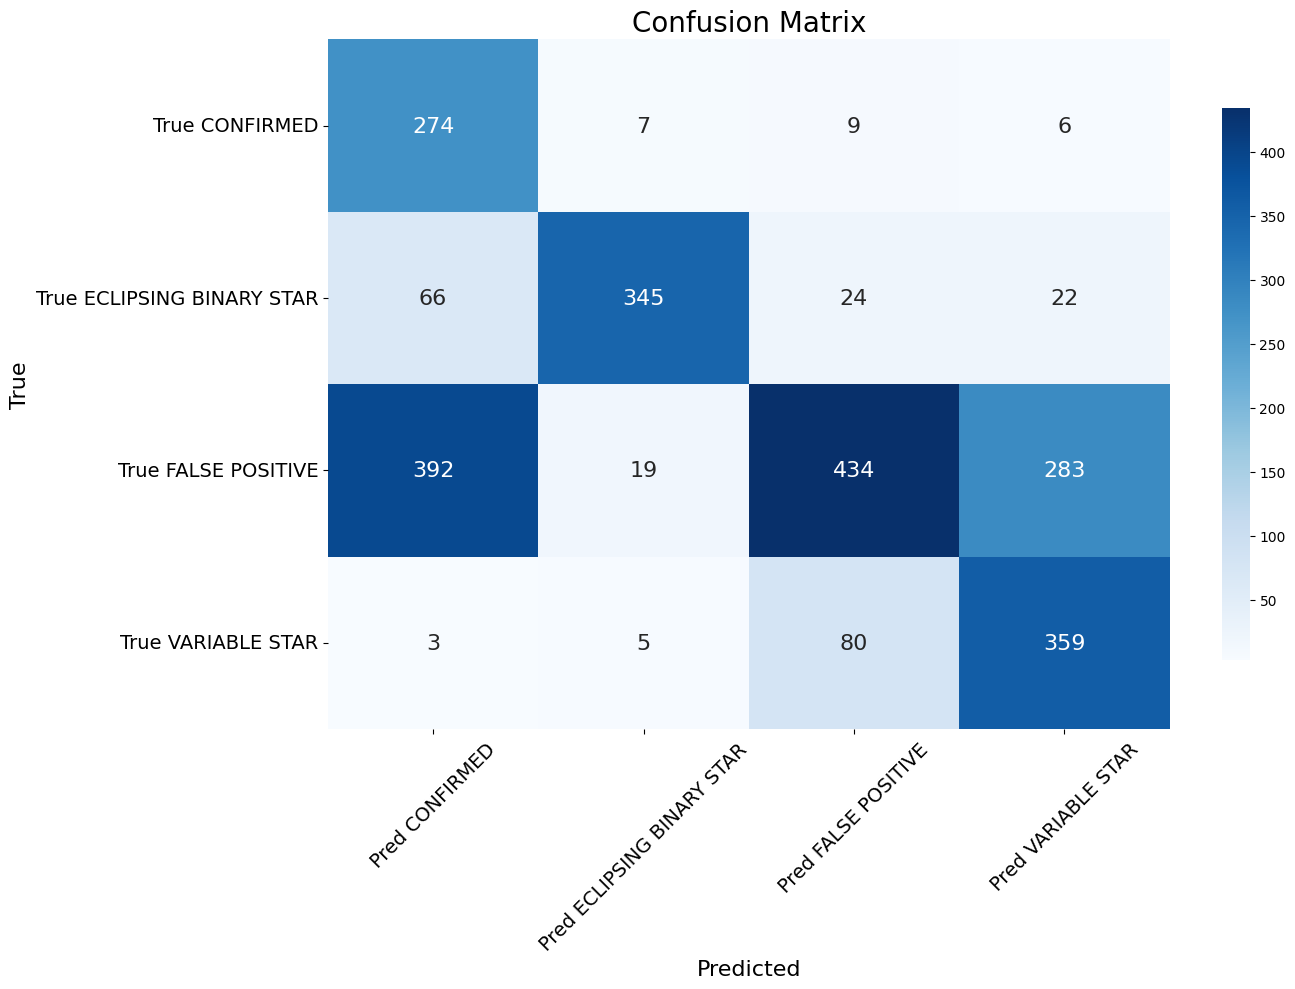

In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(cm, index=[f"True {c}" for c in class_names], columns=[f"Pred {c}" for c in class_names])
print("Confusion matrix:")
display(cm_df)

# plt.figure(figsize=(12, 8))
# sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 16},   
    cbar_kws={"shrink": 0.8}
)

plt.title("Confusion Matrix", fontsize=20)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)

plt.xticks(fontsize=14, rotation=45)
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


In [28]:
# Misclassification summary
mis_mask = y_true != y_pred
mis_df = pd.DataFrame({
    "true": y_true[mis_mask],
    "pred": y_pred[mis_mask]
})

print("Misclassification summary:")
if len(mis_df) == 0:
    print("No misclassifications.")
else:
    mis_df["pair"] = list(zip(mis_df["true"], mis_df["pred"]))
    pair_counts = mis_df["pair"].value_counts()

    pretty_pairs = []
    for (t, p), n in pair_counts.items():
        pretty_pairs.append({
            "true": class_names[int(t)] if int(t) < len(class_names) else str(t),
            "pred": class_names[int(p)] if int(p) < len(class_names) else str(p),
            "count": int(n)
        })

    display(pd.DataFrame(pretty_pairs))


Misclassification summary:


,true,pred,count
0,FALSE POSITIVE,CONFIRMED,392
1,FALSE POSITIVE,VARIABLE STAR,283
2,VARIABLE STAR,FALSE POSITIVE,80
3,ECLIPSING BINARY STAR,CONFIRMED,66
4,ECLIPSING BINARY STAR,FALSE POSITIVE,24
5,ECLIPSING BINARY STAR,VARIABLE STAR,22
6,FALSE POSITIVE,ECLIPSING BINARY STAR,19
7,CONFIRMED,FALSE POSITIVE,9
8,CONFIRMED,ECLIPSING BINARY STAR,7
9,CONFIRMED,VARIABLE STAR,6


In [30]:
labels = [0, 1, 2, 3]


In [33]:
test_metrics, test_report, test_cm, y_true, y_pred = evaluate_model(
    model, test_loader, device, labels=labels, target_names=class_names
)

print("Overall metrics:")
print(f"Accuracy:            {test_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:   {test_metrics['balanced_accuracy']:.4f}")
print(f"Macro precision:     {test_metrics['macro_precision']:.4f}")
print(f"Macro recall:        {test_metrics['macro_recall']:.4f}")
print(f"Macro F1:            {test_metrics['macro_f1']:.4f}")
print(f"Weighted precision:   {test_metrics['weighted_precision']:.4f}")
print(f"Weighted recall:      {test_metrics['weighted_recall']:.4f}")
print(f"Weighted F1:          {test_metrics['weighted_f1']:.4f}")

print("\nPer-class report:")
print(test_report)

print("Confusion matrix:")
print(test_cm)


Overall metrics:
Accuracy:            0.6065
Balanced accuracy:   0.7171
Macro precision:     0.6549
Macro recall:        0.7171
Macro F1:            0.6302
Weighted precision:   0.7148
Weighted recall:      0.6065
Weighted F1:          0.6047

Per-class report:
                       precision    recall  f1-score   support

            CONFIRMED       0.37      0.93      0.53       296
ECLIPSING BINARY STAR       0.92      0.75      0.83       457
       FALSE POSITIVE       0.79      0.38      0.52      1128
        VARIABLE STAR       0.54      0.80      0.64       447

             accuracy                           0.61      2328
            macro avg       0.65      0.72      0.63      2328
         weighted avg       0.71      0.61      0.60      2328

Confusion matrix:
[[274   7   9   6]
 [ 66 345  24  22]
 [392  19 434 283]
 [  3   5  80 359]]


In [34]:
train_metrics, train_report, train_cm, train_true, train_pred = evaluate_model(
    model, train_loader, device, labels=labels, target_names=class_names
)

val_metrics, val_report, val_cm, val_true, val_pred = evaluate_model(
    model, val_loader, device, labels=labels, target_names=class_names
)

test_metrics, test_report, test_cm, test_true, test_pred = evaluate_model(
    model, test_loader, device, labels=labels, target_names=class_names
)

print("===== FINAL RESULTS =====")

print("\nTRAIN metrics:")
print(f"Accuracy:            {train_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:   {train_metrics['balanced_accuracy']:.4f}")
print(f"Macro precision:     {train_metrics['macro_precision']:.4f}")
print(f"Macro recall:        {train_metrics['macro_recall']:.4f}")
print(f"Macro F1:            {train_metrics['macro_f1']:.4f}")
print(f"Weighted precision:  {train_metrics['weighted_precision']:.4f}")
print(f"Weighted recall:     {train_metrics['weighted_recall']:.4f}")
print(f"Weighted F1:         {train_metrics['weighted_f1']:.4f}")

print("\nVAL metrics:")
print(f"Accuracy:            {val_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:   {val_metrics['balanced_accuracy']:.4f}")
print(f"Macro precision:     {val_metrics['macro_precision']:.4f}")
print(f"Macro recall:        {val_metrics['macro_recall']:.4f}")
print(f"Macro F1:            {val_metrics['macro_f1']:.4f}")
print(f"Weighted precision:  {val_metrics['weighted_precision']:.4f}")
print(f"Weighted recall:     {val_metrics['weighted_recall']:.4f}")
print(f"Weighted F1:         {val_metrics['weighted_f1']:.4f}")

print("\nTEST metrics:")
print(f"Accuracy:            {test_metrics['accuracy']:.4f}")
print(f"Balanced accuracy:   {test_metrics['balanced_accuracy']:.4f}")
print(f"Macro precision:     {test_metrics['macro_precision']:.4f}")
print(f"Macro recall:        {test_metrics['macro_recall']:.4f}")
print(f"Macro F1:            {test_metrics['macro_f1']:.4f}")
print(f"Weighted precision:  {test_metrics['weighted_precision']:.4f}")
print(f"Weighted recall:     {test_metrics['weighted_recall']:.4f}")
print(f"Weighted F1:         {test_metrics['weighted_f1']:.4f}")

print("\nPer-class report (TEST):")
print(test_report)

print("Confusion matrix (TEST):")
print(test_cm)


===== FINAL RESULTS =====

TRAIN metrics:
Accuracy:            0.6088
Balanced accuracy:   0.7245
Macro precision:     0.6596
Macro recall:        0.7245
Macro F1:            0.6331
Weighted precision:  0.7226
Weighted recall:     0.6088
Weighted F1:         0.6051

VAL metrics:
Accuracy:            0.6065
Balanced accuracy:   0.7171
Macro precision:     0.6549
Macro recall:        0.7171
Macro F1:            0.6302
Weighted precision:  0.7148
Weighted recall:     0.6065
Weighted F1:         0.6047

TEST metrics:
Accuracy:            0.6065
Balanced accuracy:   0.7171
Macro precision:     0.6549
Macro recall:        0.7171
Macro F1:            0.6302
Weighted precision:  0.7148
Weighted recall:     0.6065
Weighted F1:         0.6047

Per-class report (TEST):
                       precision    recall  f1-score   support

            CONFIRMED       0.37      0.93      0.53       296
ECLIPSING BINARY STAR       0.92      0.75      0.83       457
       FALSE POSITIVE       0.79      0.3